In [1]:
import pandas as pd
import numpy as np
import urllib.parse as parse
import math
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

import warnings
warnings.filterwarnings('ignore')

print("Faz 2: Sağlam (Robust) Model Hazırlanıyor...")

# Temizlenmiş veri setimizi okuyoruz
try:
    df = pd.read_csv('../data/phase2_features.csv') # İsmini değiştirmediysen 'ml_ready_dataset_v4.csv' yap
    print(f"✅ Veri Yüklendi! Satır Sayısı: {df.shape[0]}")
except FileNotFoundError:
    print("❌ Dosya bulunamadı! Yol veya isim hatalı.")

Faz 2: Sağlam (Robust) Model Hazırlanıyor...
✅ Veri Yüklendi! Satır Sayısı: 106092


In [2]:
# 🚨 MODELİN KOPYA ÇEKMESİNİ ENGELLEYEN FİLTRE
yasakli_sutunlar = [
    'URL_Length', 'Host_Length', 'Parameter_Count', 'URL', 'Underscore_Count',
    'Path_Depth', # Eğik çizgi hilesini siliyoruz!
    'Has_Suspicious_Word_In_URL', # Kelime yakalamayı kural motoruna (if-else) bırakıyoruz!
    'Has_Suspicious_Word'
]

for col in yasakli_sutunlar:
    if col in df.columns:
        df = df.drop(columns=[col])

X = df.drop(columns=['Label'])
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("🎯 Modelin Eğitileceği Hilesiz Özellikler:")
print(X.columns.tolist())

🎯 Modelin Eğitileceği Hilesiz Özellikler:
['Domain_Length', 'Dot_Count', 'Hyphen_Count', 'Digit_to_Letter_Ratio', 'Shannon_Entropy', 'Subdomain_Count', 'Is_Trusted_TLD', 'Is_IP_Address', 'Has_Non_Standard_Port']


In [3]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Modeller Sözlüğüne XGBoost ve LightGBM eklendi
modeller = {
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1), # verbose=-1 gereksiz logları susturur
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Neural Network (MLP)": MLPClassifier(max_iter=1000, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVC": LinearSVC(max_iter=2000, random_state=42),
    "Naive Bayes": GaussianNB()
}

sonuclar = []
print("="*85)
print("HİLESİZ (ROBUST) ALGORİTMA KARŞILAŞTIRMA TESTİ - ŞAMPİYONLAR LİGİ".center(85))
print("="*85)

for isim, model in modeller.items():
    print(f"[{isim}] eğitiliyor...", end="")
    start_time = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    sure = time.time() - start_time
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    sonuclar.append([isim, acc, prec, rec, f1, sure])
    print(f" Tamamlandı! ({sure:.2f} sn)")

# Liderlik Tablosunu Oluşturma
leaderboard = pd.DataFrame(sonuclar, columns=['Algoritma', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Süre (sn)'])
leaderboard = leaderboard.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*85)
print("NİHAİ LİDERLİK TABLOSU (LEADERBOARD)".center(85))
print("="*85)
print(leaderboard.to_string(index=False))

          HİLESİZ (ROBUST) ALGORİTMA KARŞILAŞTIRMA TESTİ - ŞAMPİYONLAR LİGİ          
[LightGBM] eğitiliyor...


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


 Tamamlandı! (2.22 sn)
[XGBoost] eğitiliyor... Tamamlandı! (0.40 sn)
[Random Forest] eğitiliyor... Tamamlandı! (2.77 sn)
[Gradient Boosting] eğitiliyor... Tamamlandı! (2.95 sn)
[K-Nearest Neighbors] eğitiliyor... Tamamlandı! (2.11 sn)
[Decision Tree] eğitiliyor... Tamamlandı! (0.07 sn)
[Neural Network (MLP)] eğitiliyor... Tamamlandı! (24.79 sn)
[Logistic Regression] eğitiliyor... Tamamlandı! (0.20 sn)
[Linear SVC] eğitiliyor... Tamamlandı! (0.10 sn)
[Naive Bayes] eğitiliyor... Tamamlandı! (0.02 sn)

                         NİHAİ LİDERLİK TABLOSU (LEADERBOARD)                        
           Algoritma  Accuracy  Precision   Recall  F1-Score  Süre (sn)
            LightGBM  0.900985   0.938281 0.869953  0.902826   2.221637
             XGBoost  0.900561   0.936380 0.871112  0.902567   0.396286
       Random Forest  0.899336   0.930760 0.874677  0.901847   2.765331
       Decision Tree  0.897969   0.931307 0.871290  0.900299   0.070641
 K-Nearest Neighbors  0.896602   0.924626 0.87583

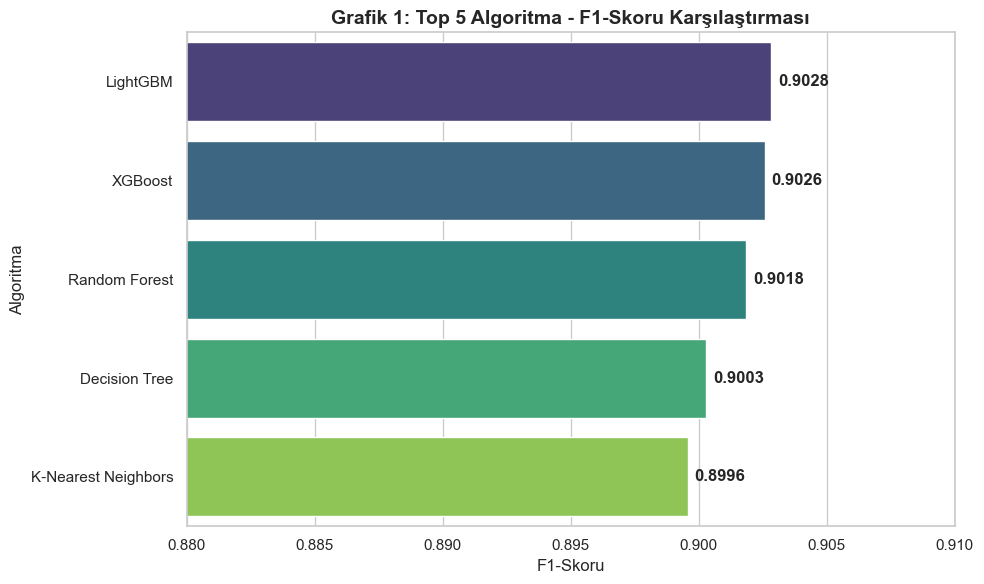

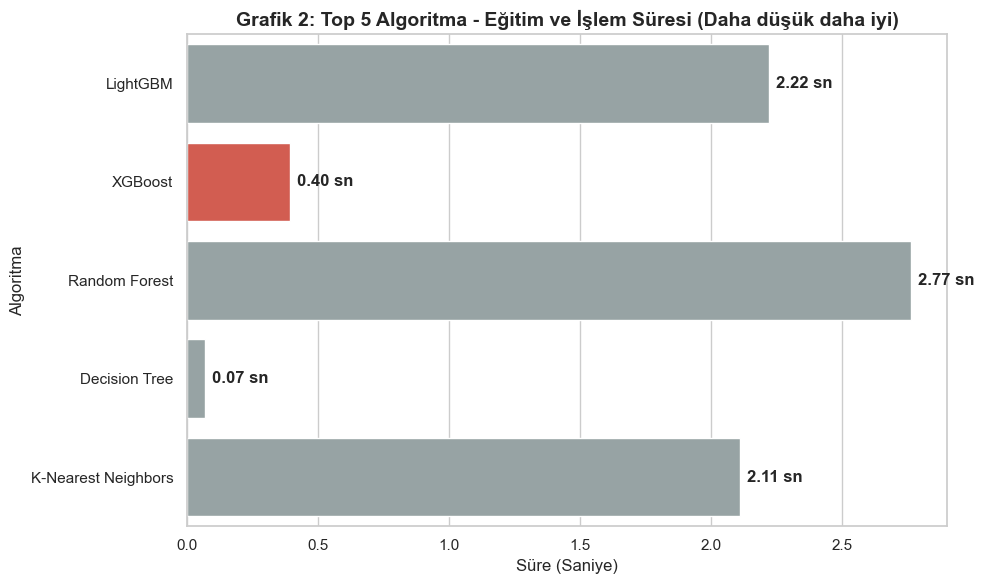

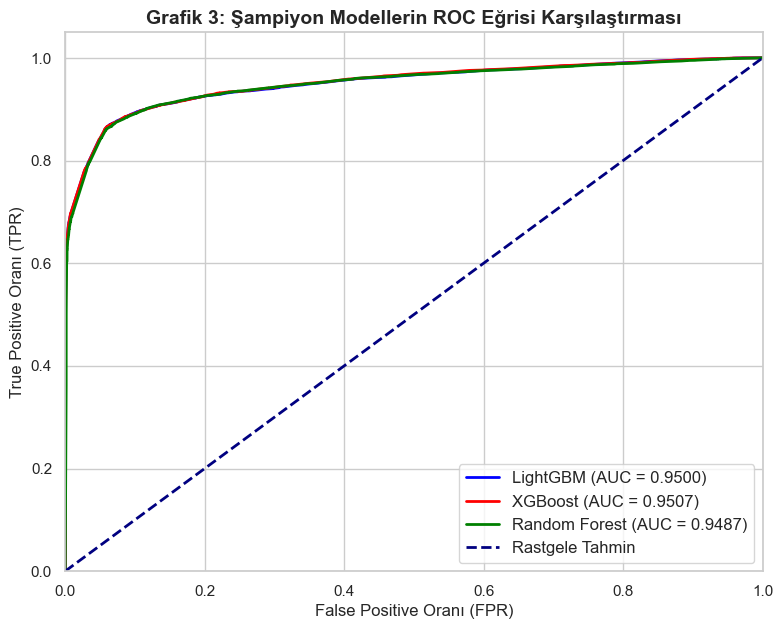

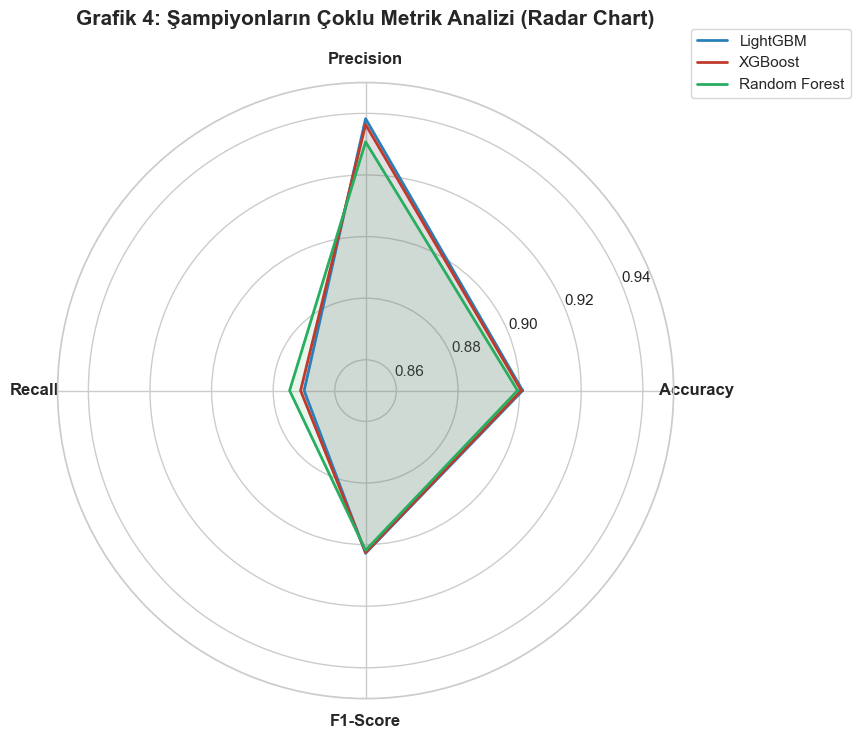

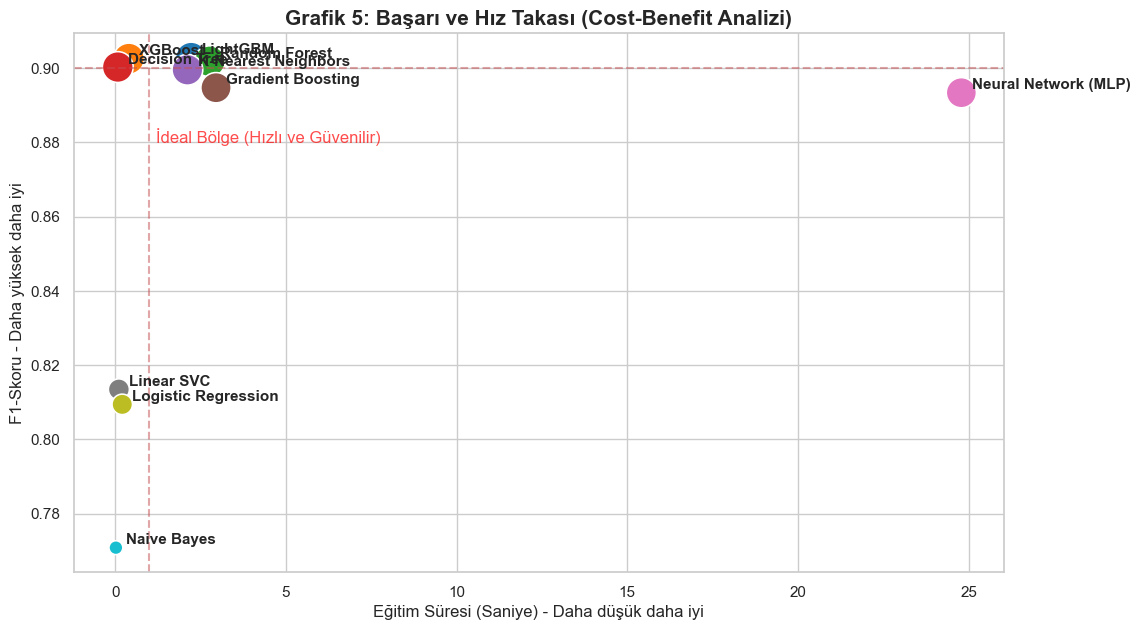

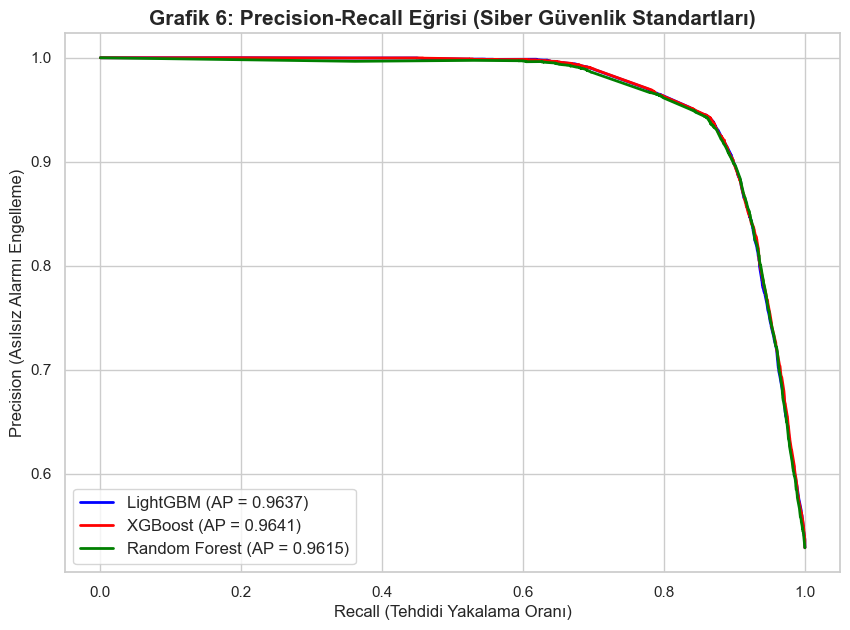

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Akademik stil ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Liderlik tablosundan en iyi 5 modeli alalım (Görsel çok kalabalık olmasın)
top5_models = leaderboard.head(5)

# ==========================================
# GRAFİK 1: F1-SKORU KARŞILAŞTIRMASI (BAR CHART)
# ==========================================
plt.figure(figsize=(10, 6))
g = sns.barplot(x="F1-Score", y="Algoritma", data=top5_models, palette="viridis")
plt.title('Grafik 1: Top 5 Algoritma - F1-Skoru Karşılaştırması', fontsize=14, fontweight='bold')
plt.xlabel('F1-Skoru', fontsize=12)
plt.ylabel('Algoritma', fontsize=12)
plt.xlim(0.88, 0.91) # Farkları net görmek için ekseni daraltıyoruz

# Barların sonuna skorları yazalım
for p in g.patches:
    g.annotate(f"{p.get_width():.4f}", 
               (p.get_width(), p.get_y() + p.get_height() / 2.), 
               ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# GRAFİK 2: EĞİTİM SÜRESİ KARŞILAŞTIRMASI (HIZ TESTİ)
# ==========================================
plt.figure(figsize=(10, 6))
# XGBoost'un hızını vurgulamak için onu kırmızı, diğerlerini gri yapalım
renkler = ['#e74c3c' if algo == 'XGBoost' else '#95a5a6' for algo in top5_models["Algoritma"]]

g2 = sns.barplot(x="Süre (sn)", y="Algoritma", data=top5_models, palette=renkler)
plt.title('Grafik 2: Top 5 Algoritma - Eğitim ve İşlem Süresi (Daha düşük daha iyi)', fontsize=14, fontweight='bold')
plt.xlabel('Süre (Saniye)', fontsize=12)
plt.ylabel('Algoritma', fontsize=12)

# Barların sonuna süreleri yazalım
for p in g2.patches:
    g2.annotate(f"{p.get_width():.2f} sn", 
               (p.get_width(), p.get_y() + p.get_height() / 2.), 
               ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# GRAFİK 3: ŞAMPİYONLARIN ROC EĞRİLERİ (RF vs XGBoost vs LightGBM)
# ==========================================
plt.figure(figsize=(9, 7))

# Sadece top 3 modeli hızlıca tahmin ettirip ROC çizdirelim
top3_isimler = ["LightGBM", "XGBoost", "Random Forest"]
renk_paleti = {'LightGBM': 'blue', 'XGBoost': 'red', 'Random Forest': 'green'}

for isim in top3_isimler:
    model = modeller[isim]
    # predict_proba ile olasılıkları alıyoruz
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Çizgi kalınlıkları ve renkleri
    plt.plot(fpr, tpr, color=renk_paleti[isim], lw=2, label=f'{isim} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı (FPR)', fontsize=12)
plt.ylabel('True Positive Oranı (TPR)', fontsize=12)
plt.title('Grafik 3: Şampiyon Modellerin ROC Eğrisi Karşılaştırması', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.show()

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score

# Akademik stil ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================
# GRAFİK 4: ÇOKLU METRİK RADAR (SPIDER) GRAFİĞİ
# (Top 3 Modelin tüm alanlardaki dengesini gösterir)
# ==========================================
# Metrikler ve açılar
kategoriler = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(kategoriler)
acilar = [n / float(N) * 2 * np.pi for n in range(N)]
acilar += acilar[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
renkler = ['#2980b9', '#c0392b', '#27ae60']

top3_modeller = leaderboard.head(3)
for index, row in top3_modeller.iterrows():
    degerler = row[['Accuracy', 'Precision', 'Recall', 'F1-Score']].values.flatten().tolist()
    degerler += degerler[:1]
    
    ax.plot(acilar, degerler, linewidth=2, linestyle='solid', label=row['Algoritma'], color=renkler[index])
    ax.fill(acilar, degerler, alpha=0.1, color=renkler[index])

plt.xticks(acilar[:-1], kategoriler, size=12, fontweight='bold')
ax.set_ylim(0.85, 0.95) # Farkı net görmek için ekseni yakınlaştırıyoruz
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.title("Grafik 4: Şampiyonların Çoklu Metrik Analizi (Radar Chart)", fontsize=15, fontweight='bold', y=1.08)
plt.show()

# ==========================================
# GRAFİK 5: HIZ VE BAŞARI TAKASI (SCATTER PLOT)
# (Maliyet-Performans Analizinin Zirvesi)
# ==========================================
plt.figure(figsize=(12, 7))
# En iyi F1 skoru yüksek, Eğitim süresi düşük olandır (Sol Üst Köşe)
g = sns.scatterplot(data=leaderboard, x="Süre (sn)", y="F1-Score", 
                    hue="Algoritma", size="F1-Score", sizes=(100, 500), palette="tab10", legend=False)

# Noktaların yanına isimlerini yazalım
for i in range(leaderboard.shape[0]):
    # Üst üste binmesin diye hafif kaydırmalar yapıyoruz
    offset_x = 0.3
    offset_y = 0.001
    plt.text(x=leaderboard['Süre (sn)'][i] + offset_x, 
             y=leaderboard['F1-Score'][i] + offset_y,
             s=leaderboard['Algoritma'][i], 
             fontdict=dict(size=11, fontweight='bold'))

# En iyi bölgeyi (Sweet Spot) işaretleyelim
plt.axvline(x=1.0, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.5)
plt.text(1.2, 0.88, "İdeal Bölge (Hızlı ve Güvenilir)", color='red', fontsize=12, alpha=0.7)

plt.title("Grafik 5: Başarı ve Hız Takası (Cost-Benefit Analizi)", fontsize=15, fontweight='bold')
plt.xlabel('Eğitim Süresi (Saniye) - Daha düşük daha iyi', fontsize=12)
plt.ylabel('F1-Skoru - Daha yüksek daha iyi', fontsize=12)
plt.show()

# ==========================================
# GRAFİK 6: PRECISION-RECALL (PR) EĞRİSİ
# (Siber Güvenlikte ROC'tan daha kritiktir)
# ==========================================
plt.figure(figsize=(10, 7))
top3_isimler = ["LightGBM", "XGBoost", "Random Forest"]
renk_paleti = {'LightGBM': 'blue', 'XGBoost': 'red', 'Random Forest': 'green'}

for isim in top3_isimler:
    model = modeller[isim]
    # Predict_proba fonksiyonu Neural Network gibi bazı modellerde hata verebilir ama top 3'te sorunsuzdur
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    
    plt.plot(recall, precision, color=renk_paleti[isim], lw=2, label=f'{isim} (AP = {ap:.4f})')

plt.xlabel('Recall (Tehdidi Yakalama Oranı)', fontsize=12)
plt.ylabel('Precision (Asılsız Alarmı Engelleme)', fontsize=12)
plt.title('Grafik 6: Precision-Recall Eğrisi (Siber Güvenlik Standartları)', fontsize=15, fontweight='bold')
plt.legend(loc="lower left", fontsize=12)
plt.show()

Akademik Grafikler Üretiliyor...


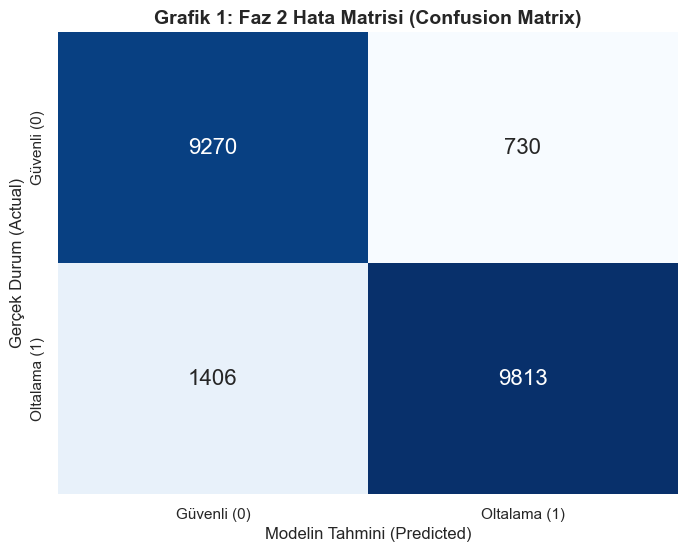

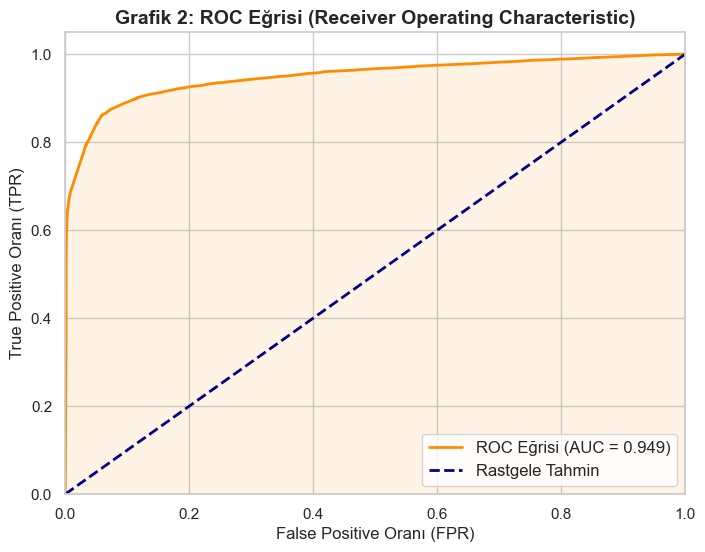

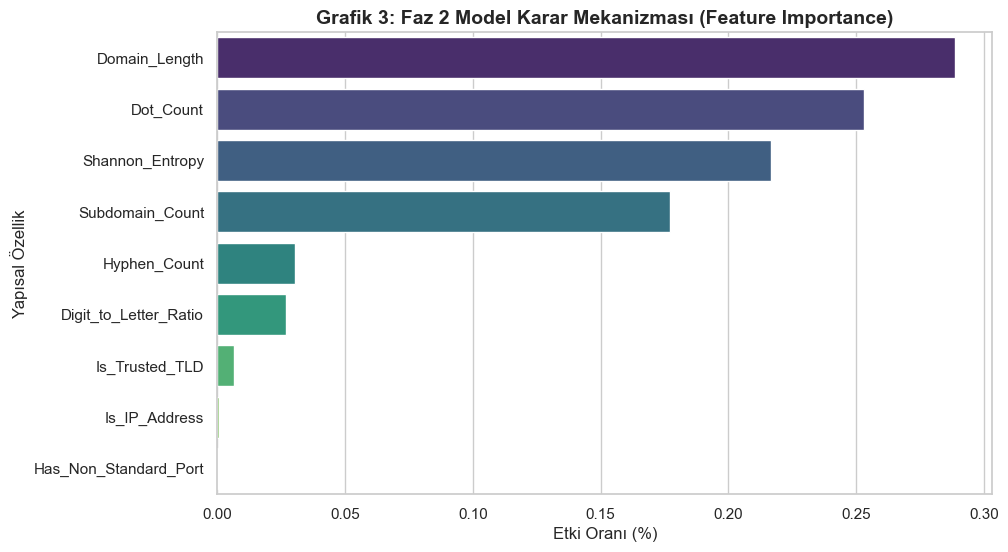

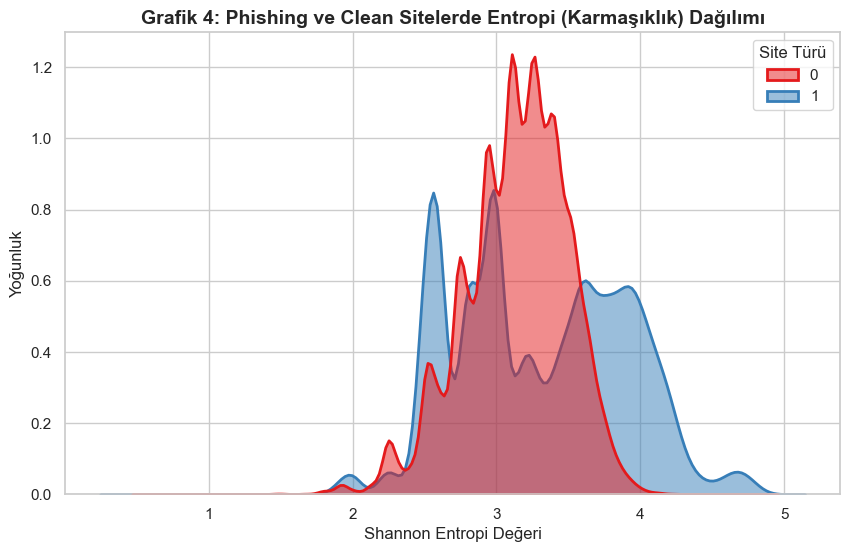

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Grafik arka plan stilini akademik formata getirelim
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Akademik Grafikler Üretiliyor...")

# Veriyi Hazırlama (Emin olmak için hızlıca RF eğitiyoruz)
df = pd.read_csv('../data/phase2_features.csv')
yasakli = ['URL_Length', 'Host_Length', 'Parameter_Count', 'URL', 'Underscore_Count', 'Path_Depth', 'Has_Suspicious_Word_In_URL', 'Has_Suspicious_Word']
for col in yasakli:
    if col in df.columns: df = df.drop(columns=[col])

X = df.drop(columns=['Label'])
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# ==========================================
# GRAFİK 1: HATA MATRİSİ (CONFUSION MATRIX)
# ==========================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 16})
plt.title('Grafik 1: Faz 2 Hata Matrisi (Confusion Matrix)', fontsize=14, fontweight='bold')
plt.xlabel('Modelin Tahmini (Predicted)', fontsize=12)
plt.ylabel('Gerçek Durum (Actual)', fontsize=12)
plt.xticks([0.5, 1.5], ['Güvenli (0)', 'Oltalama (1)'], fontsize=11)
plt.yticks([0.5, 1.5], ['Güvenli (0)', 'Oltalama (1)'], fontsize=11, va='center')
plt.show()

# ==========================================
# GRAFİK 2: ROC EĞRİSİ VE AUC SKORU
# ==========================================
plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı (FPR)', fontsize=12)
plt.ylabel('True Positive Oranı (TPR)', fontsize=12)
plt.title('Grafik 2: ROC Eğrisi (Receiver Operating Characteristic)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.show()

# ==========================================
# GRAFİK 3: ÖZELLİK ÖNEM DERECESİ (FEATURE IMPORTANCE)
# ==========================================
plt.figure(figsize=(10, 6))
importances = rf.feature_importances_
feature_df = pd.DataFrame({"Özellik": X.columns, "Önem": importances}).sort_values(by="Önem", ascending=False)

sns.barplot(x="Önem", y="Özellik", data=feature_df, palette="viridis")
plt.title('Grafik 3: Faz 2 Model Karar Mekanizması (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Etki Oranı (%)', fontsize=12)
plt.ylabel('Yapısal Özellik', fontsize=12)
plt.show()

# ==========================================
# GRAFİK 4: ENTROPİ DAĞILIMI (SHANNON ENTROPY KDE PLOT)
# ==========================================
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="Shannon_Entropy", hue="Label", fill=True, common_norm=False, palette="Set1", alpha=0.5, linewidth=2)
plt.title('Grafik 4: Phishing ve Clean Sitelerde Entropi (Karmaşıklık) Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Shannon Entropi Değeri', fontsize=12)
plt.ylabel('Yoğunluk', fontsize=12)
legend = plt.gca().get_legend()
if legend: legend.set_title("Site Türü")
plt.show()

Akademik Grafikler Üretiliyor (XGBoost Engine)...


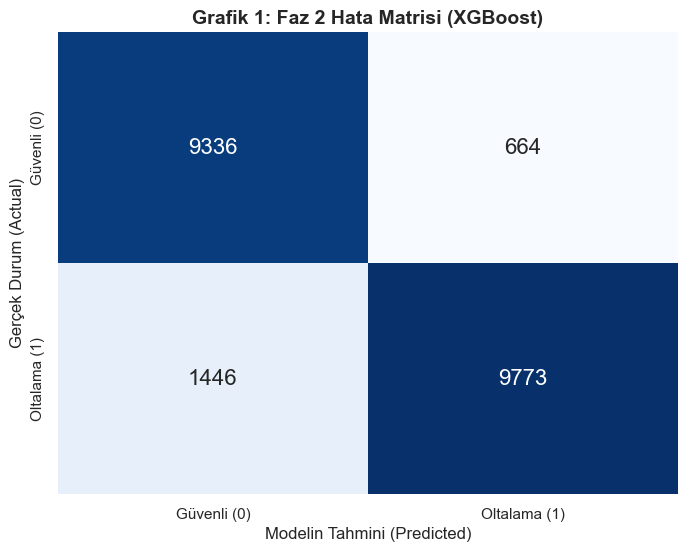

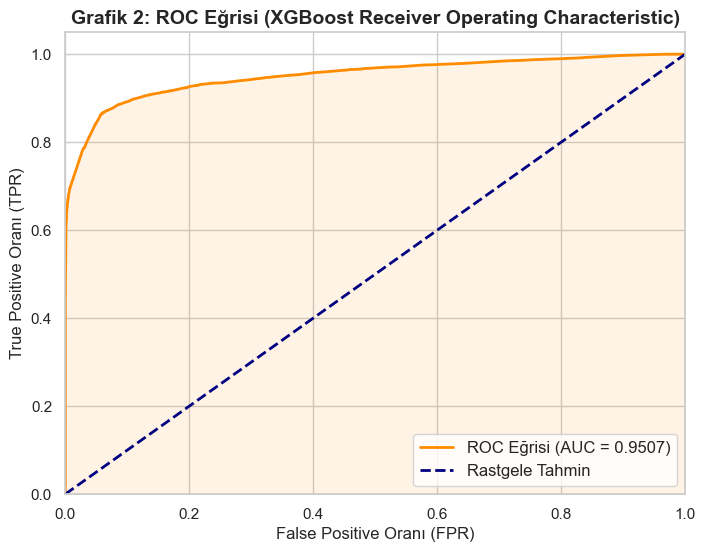

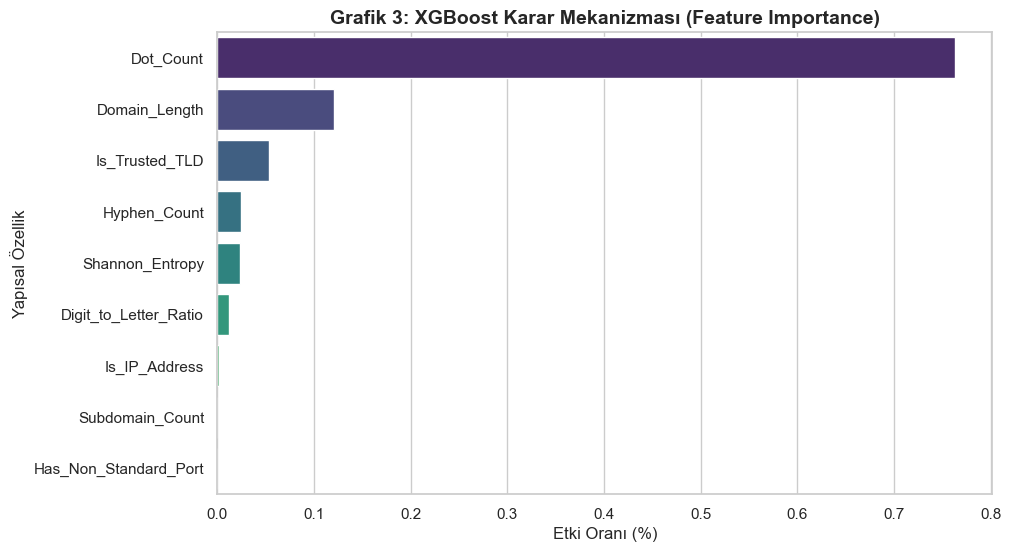

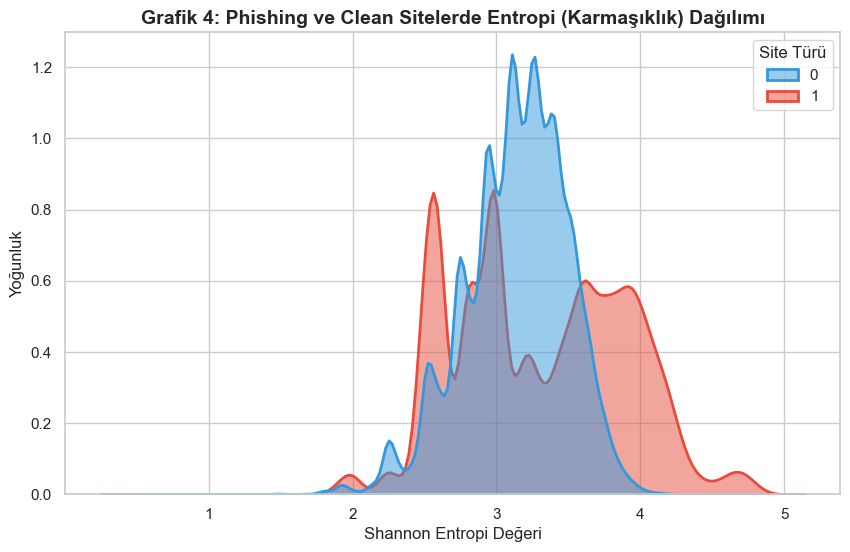

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier  # 🌟 Random Forest yerine şampiyonumuz eklendi

# Grafik arka plan stilini akademik formata getirelim
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Akademik Grafikler Üretiliyor (XGBoost Engine)...")

# Veriyi Hazırlama
df = pd.read_csv('../data/phase2_features.csv')
yasakli = ['URL_Length', 'Host_Length', 'Parameter_Count', 'URL', 'Underscore_Count', 'Path_Depth', 'Has_Suspicious_Word_In_URL', 'Has_Suspicious_Word']
for col in yasakli:
    if col in df.columns: df = df.drop(columns=[col])

X = df.drop(columns=['Label'])
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 🌟 XGBoost Modelini Eğitme
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

# ==========================================
# GRAFİK 1: HATA MATRİSİ (CONFUSION MATRIX)
# ==========================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 16})
plt.title('Grafik 1: Faz 2 Hata Matrisi (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Modelin Tahmini (Predicted)', fontsize=12)
plt.ylabel('Gerçek Durum (Actual)', fontsize=12)
plt.xticks([0.5, 1.5], ['Güvenli (0)', 'Oltalama (1)'], fontsize=11)
plt.yticks([0.5, 1.5], ['Güvenli (0)', 'Oltalama (1)'], fontsize=11, va='center')
plt.show()

# ==========================================
# GRAFİK 2: ROC EĞRİSİ VE AUC SKORU
# ==========================================
plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı (FPR)', fontsize=12)
plt.ylabel('True Positive Oranı (TPR)', fontsize=12)
plt.title('Grafik 2: ROC Eğrisi (XGBoost Receiver Operating Characteristic)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.show()

# ==========================================
# GRAFİK 3: ÖZELLİK ÖNEM DERECESİ (FEATURE IMPORTANCE)
# ==========================================
plt.figure(figsize=(10, 6))
# 🌟 XGBoost'un feature_importances_ fonksiyonu kullanılıyor
importances = xgb.feature_importances_
feature_df = pd.DataFrame({"Özellik": X.columns, "Önem": importances}).sort_values(by="Önem", ascending=False)

sns.barplot(x="Önem", y="Özellik", data=feature_df, palette="viridis")
plt.title('Grafik 3: XGBoost Karar Mekanizması (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Etki Oranı (%)', fontsize=12)
plt.ylabel('Yapısal Özellik', fontsize=12)
plt.show()

# ==========================================
# GRAFİK 4: ENTROPİ DAĞILIMI (SHANNON ENTROPY KDE PLOT)
# ==========================================
plt.figure(figsize=(10, 6))
# 🌟 Renk paleti siber güvenlik standartlarına uygun olarak güncellendi (0=Mavi, 1=Kırmızı)
sns.kdeplot(data=df, x="Shannon_Entropy", hue="Label", fill=True, common_norm=False, palette=['#3498db', '#e74c3c'], alpha=0.5, linewidth=2)
plt.title('Grafik 4: Phishing ve Clean Sitelerde Entropi (Karmaşıklık) Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Shannon Entropi Değeri', fontsize=12)
plt.ylabel('Yoğunluk', fontsize=12)
legend = plt.gca().get_legend()
if legend: legend.set_title("Site Türü")
plt.show()

In [ ]:
import pandas as pd
import urllib.parse as parse
import math
import re

def live_predict_robust(test_url):
    features = {}
    try:
        parsed = parse.urlparse(test_url)
        domain = str(parsed.hostname) if parsed.hostname else test_url
        port = parsed.port
        if domain.startswith('www.'): domain = domain[4:]
    except Exception:
        domain = test_url
        port = None

    def calculate_entropy(text):
        if not text: return 0
        entropy = 0
        for x in set(text):
            p_x = float(text.count(x)) / len(text)
            entropy += - p_x * math.log(p_x, 2)
        return entropy

    # Modelin Beklediği 9 Özellik (Feature Extraction)
    features['Domain_Length'] = len(domain)
    features['Dot_Count'] = domain.count('.')
    features['Hyphen_Count'] = domain.count('-')
    digits = sum(c.isdigit() for c in domain)
    features['Digit_to_Letter_Ratio'] = (digits / (len(domain) - digits)) if (len(domain) - digits) > 0 else 0
    features['Shannon_Entropy'] = calculate_entropy(domain)
    features['Subdomain_Count'] = domain.count('.') 
    trusted_tlds = ['.edu', '.edu.tr', '.gov', '.gov.tr', '.mil', '.bel.tr', '.k12.tr']
    features['Is_Trusted_TLD'] = 1 if any(domain.endswith(tld) for tld in trusted_tlds) else 0
    features['Is_IP_Address'] = 1 if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", domain) else 0
    features['Has_Non_Standard_Port'] = 1 if port is not None and port not in [80, 443] else 0
    
    # Modele Gönderme Formatı
    df_features = pd.DataFrame([features])
    for col in X_train.columns:
        if col not in df_features.columns: df_features[col] = 0
    df_features = df_features[X_train.columns] 
    
    # 🌟 ŞAMPİYON MODEL ENJEKSİYONU: XGBoost
    best_model = modeller["XGBoost"]
    probabilities = best_model.predict_proba(df_features)[0]

    # 🌟 MÜHENDİSLİK: %30 Security Threshold (Güvenlik Eşiği)
    SECURITY_THRESHOLD = 0.30 
    prediction = 1 if probabilities[1] >= SECURITY_THRESHOLD else 0

    # 🌟 SİBER GÜVENLİK (HEURISTIC) MÜDAHALE KATMANI
    suspicious_words = ['secure', 'login', 'update', 'verify', 'account', 'auth', 'free']
    
    # 1. Kesin Tehditler (IP Address or Non-Standard Port)
    if features['Is_IP_Address'] == 1 or features['Has_Non_Standard_Port'] == 1:
        prediction = 1; probabilities[1] = 1.0 
        print("   -> [HEURISTIC KURAL] Doğrudan IP veya Standart Dışı Port Tespit Edildi!")
        
    # 2. Şüpheli Kelime Yakalayıcı (Suspicious Keywords in non-trusted domains)
    elif any(word in test_url.lower() for word in suspicious_words) and features['Is_Trusted_TLD'] == 0:
        prediction = 1; probabilities[1] = 0.95 
        print("   -> [HEURISTIC KURAL] URL içinde oltalama anahtar kelimesi (keyword) bulundu!")
        
    # 3. GÜVENİLİR KURUM TOLERANSI (Trusted TLD Whitelist)
    elif features['Is_Trusted_TLD'] == 1 and probabilities[1] < 0.85:
        prediction = 0; probabilities[0] = 1.0 
        print("   -> [HEURISTIC KURAL] Akademik/Resmi TLD tespit edildi, Güven Skoru (Confidence) artırıldı!")
    
    print("=" * 65)
    print(f"🔍 Test Edilen URL : {test_url}")
    print("-" * 65)
    if prediction == 1:
        print(f"🚨 TESPİT        : PHISHING (OLTALAMA SİTESİ) !!!")
        print(f"⚠️ Threat Score  : % {probabilities[1]*100:.2f}")
    else:
        print(f"✅ TESPİT        : CLEAN (GÜVENLİ SİTE)")
        print(f"🛡️ Confidence    : % {probabilities[0]*100:.2f}")
    print("=" * 65 + "\n")

# ==========================================
# 🧪 YENİ VE ZORLAYICI (SOC SEVİYESİ) TESTLER
# ==========================================

# 1. Standart Phishing (Tireli ve karmaşık)
live_predict_robust("http://ptt-kargo-teslimat-onayi.com/login.php?user=19283")

# 2. Resmi Kurum (False Positive Testi)
live_predict_robust("https://debis.deu.edu.tr/debis.php")

# 3. Kısa ve Parametresiz Temiz Site (Lexical kontrolü)
live_predict_robust("https://www.oyunskor.com/")

# 4. Yüksek Entropili ama TEMİZ proje linki (Github repoları çok karmaşık görünür, modelin şaşırmaması lazım)
live_predict_robust("https://github.com/salimtaha/net-scanner/blob/main/mac_changer.py")

# 5. Siber Güvenlik Platformu Taklidi (Hedefli Phishing / Suspicious word)
live_predict_robust("https://accounts.google.com/v3/signin/identifier?authuser=0&continue=https%3A%2F%2Fmyaccount.google.com%2F&ec=GAlAwAE&hl=tr&service=accountsettings&flowName=GlifWebSignIn&flowEntry=AddSession&dsh=S1664219096%3A1777544434416325")

# 6. Oyuncu Hedefli Punycode/Homograph Saldırısı (Tireler ve anlamsız karakterler)
live_predict_robust("https://steam-rocketleague-free-credits.xn--com-9o0a")

# 7. Doğrudan IP ve Port Üzerinden Sızma Girişimi
live_predict_robust("https://192.168.1.15:8080/admin_panel")

   -> [HEURISTIC KURAL] URL içinde oltalama anahtar kelimesi (keyword) bulundu!
🔍 Test Edilen URL : http://ptt-kargo-teslimat-onayi.com/login.php?user=19283
-----------------------------------------------------------------
🚨 TESPİT        : PHISHING (OLTALAMA SİTESİ) !!!
⚠️ Threat Score  : % 95.00

   -> [HEURISTIC KURAL] Akademik/Resmi TLD tespit edildi, Güven Skoru (Confidence) artırıldı!
🔍 Test Edilen URL : https://debis.deu.edu.tr/debis.php
-----------------------------------------------------------------
✅ TESPİT        : CLEAN (GÜVENLİ SİTE)
🛡️ Confidence    : % 100.00

🔍 Test Edilen URL : https://www.oyunskor.com/
-----------------------------------------------------------------
✅ TESPİT        : CLEAN (GÜVENLİ SİTE)
🛡️ Confidence    : % 93.98

🔍 Test Edilen URL : https://github.com/salimtaha/net-scanner/blob/main/mac_changer.py
-----------------------------------------------------------------
✅ TESPİT        : CLEAN (GÜVENLİ SİTE)
🛡️ Confidence    : % 88.87

   -> [HEURISTIC KU

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import joblib

# 1. VERİ HAZIRLIĞI (Kernel boşaldığı için baştan alıyoruz)
df = pd.read_csv('../data/phase2_features.csv')
yasakli = ['URL_Length', 'Host_Length', 'Parameter_Count', 'URL', 'Underscore_Count', 'Path_Depth', 'Has_Suspicious_Word_In_URL', 'Has_Suspicious_Word']
for col in yasakli:
    if col in df.columns: df = df.drop(columns=[col])

X = df.drop(columns=['Label'])
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Veri hazırlandı, XGBoost eğitiliyor...")

# 2. ŞAMPİYON MODELİ YENİDEN EĞİTME (`xgb` değişkenini yaratıyoruz)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

# 3. MODELİ VE ÖZELLİKLERİ KAYDETME
joblib.dump(xgb, 'xgboost_waf_model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

print("✅ Şampiyon XGBoost Modeli ve özellikleri (Columns) başarıyla kaydedildi! Artık Streamlit arayüzüne geçebilirsin.")

Veri hazırlandı, XGBoost eğitiliyor...
✅ Şampiyon XGBoost Modeli ve özellikleri (Columns) başarıyla kaydedildi! Artık Streamlit arayüzüne geçebilirsin.


c:\Users\tahak\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:37:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
